In [1]:
# Correlation:
# Moves a filter (kernel) over an image and computes a weighted sum.
# It does NOT flip the kernel before applying.
# Used for template matching and feature detection.

# Convolution:
# Similar to correlation but flips the filter before applying.
# Used in CNNs and deep learning for feature extraction.
# Helps with mathematical consistency in gradient calculations.

# Filter (Kernel):
# A small matrix (e.g., 3x3 or 5x5) that transforms an image when applied.
# Can be used for blurring, sharpening, and edge detection.
# Applied using either correlation or convolution.

# Mask:
# A binary filter (only 0s and 1s) that selects or removes parts of an image.
# Used for image segmentation and region-based processing.
# Example: A mask can isolate an object while removing the background.


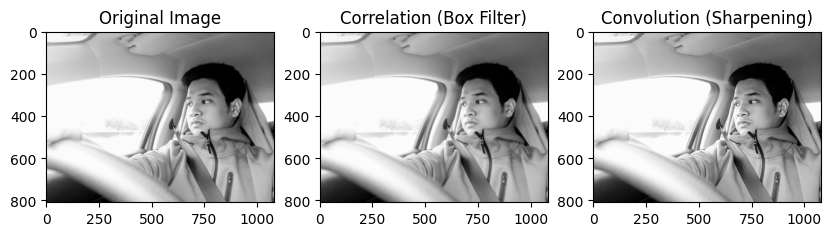

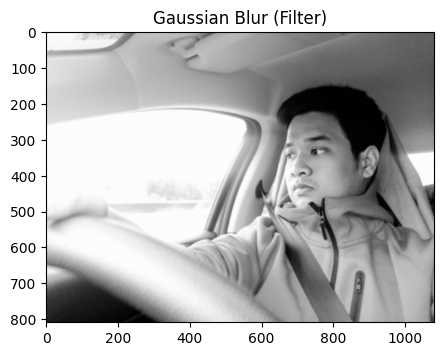

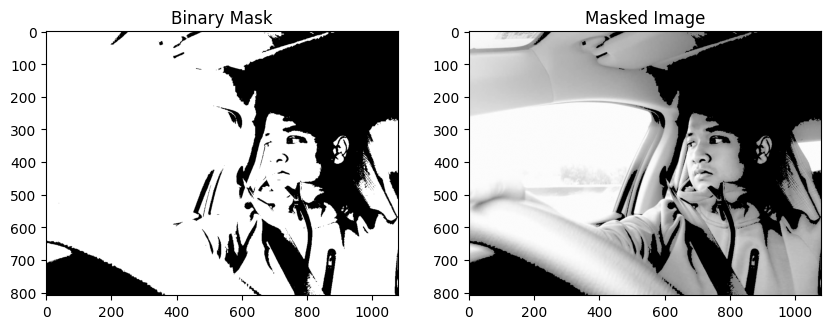

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image in grayscale for simplicity
image = cv2.imread("khoi.jpg", cv2.IMREAD_GRAYSCALE)

# Show original image
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")

# ==========================
# 1️⃣ Correlation (Cross-Correlation)
# ==========================
# Define a simple 3x3 averaging filter (box filter)
correlation_kernel = np.ones((3, 3), np.float32) / 9

# Apply correlation (cv2.filter2D applies kernel without flipping)
correlation_result = cv2.filter2D(image, -1, correlation_kernel)

# Show correlation result
plt.subplot(1, 3, 2)
plt.imshow(correlation_result, cmap="gray")
plt.title("Correlation (Box Filter)")

# ==========================
# 2️⃣ Convolution (Flipped Kernel)
# ==========================
# Define a simple sharpening kernel
convolution_kernel = np.array([[ 0, -1,  0],
                                [-1,  5, -1],
                                [ 0, -1,  0]], np.float32)

# Apply convolution (cv2.filter2D automatically flips the kernel)
convolution_result = cv2.filter2D(image, -1, convolution_kernel)

# Show convolution result
plt.subplot(1, 3, 3)
plt.imshow(convolution_result, cmap="gray")
plt.title("Convolution (Sharpening)")

plt.show()

# ==========================
# 3️⃣ Filter (Kernel Application)
# ==========================
# Gaussian blur (a type of filter that smooths the image)
gaussian_blur = cv2.GaussianBlur(image, (5,5), 0)

# Show the Gaussian blurred image
plt.figure(figsize=(5, 5))
plt.imshow(gaussian_blur, cmap="gray")
plt.title("Gaussian Blur (Filter)")
plt.show()

# ==========================
# 4️⃣ Mask (Binary Image Segmentation)
# ==========================
# Create a binary mask where pixels > 128 are set to 255, others to 0
_, mask = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)

# Apply the mask to keep only certain parts of the image
masked_image = cv2.bitwise_and(image, image, mask=mask)

# Show the mask and the masked image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.title("Binary Mask")

plt.subplot(1, 2, 2)
plt.imshow(masked_image, cmap="gray")
plt.title("Masked Image")
plt.show()
